# Cross-Channel Correlation (37x37) and Noise Correlation Matrix

This notebook computes and plots:
1. Cross-channel correlation matrix (`37x37`) from the selected channels.
2. Noise-only correlation matrix using `noise = traces_MMC - traces_clean`.
3. A significant-correlation view (high absolute correlation only), where independent channels should leave mostly diagonal entries.


In [1]:
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')
np.set_printoptions(precision=4, suppress=True)


In [2]:
# Config
PAIR_QP_FILE = Path('/ceph/dwong/trigger_samples/PCA_QP/main/NR_traces_energy_500_pair_batch_0000.h5')
TARGET_CHANNELS = 37
MAX_EVENTS = 120
SIGNIFICANCE_ABS_THRESHOLD = 0.15  # magnitude threshold for display significance
RNG_SEED = 20260311

print('PAIR_QP_FILE:', PAIR_QP_FILE)
print('TARGET_CHANNELS:', TARGET_CHANNELS)
print('MAX_EVENTS:', MAX_EVENTS)


PAIR_QP_FILE: /ceph/dwong/trigger_samples/PCA_QP/main/NR_traces_energy_500_pair_batch_0000.h5
TARGET_CHANNELS: 37
MAX_EVENTS: 120


In [3]:
def _flatten_channels(x):
    # Input: (n_events, n_channels, n_samples)
    # Output: (n_channels, n_events * n_samples)
    return x.transpose(1, 0, 2).reshape(x.shape[1], -1)


def _channel_corr(x):
    # x expected shape: (n_channels, n_points)
    return np.corrcoef(x)


if PAIR_QP_FILE.exists():
    with h5py.File(PAIR_QP_FILE, 'r') as f:
        mmc_ds = f['traces_MMC']
        clean_ds = f['traces_clean']

        n_events, n_channels, n_samples = mmc_ds.shape
        n_use = min(MAX_EVENTS, n_events)

        if n_channels < TARGET_CHANNELS:
            raise ValueError(f'File has only {n_channels} channels, but TARGET_CHANNELS={TARGET_CHANNELS}.')

        # Use the last 37 channels by convention in this repo's workflows.
        mmc = np.asarray(mmc_ds[:n_use, -TARGET_CHANNELS:, :], dtype=np.float32)
        clean = np.asarray(clean_ds[:n_use, -TARGET_CHANNELS:, :], dtype=np.float32)

    source_info = f'real data: {PAIR_QP_FILE}'
else:
    # Fallback so plotting code is always runnable
    rng = np.random.default_rng(RNG_SEED)
    n_use = MAX_EVENTS
    n_samples = 4096
    mmc = rng.normal(0, 1.0, size=(n_use, TARGET_CHANNELS, n_samples)).astype(np.float32)
    clean = np.zeros_like(mmc)
    source_info = 'synthetic fallback: independent Gaussian noise'

noise = mmc - clean

mmc_flat = _flatten_channels(mmc)
noise_flat = _flatten_channels(noise)

cross_corr = _channel_corr(mmc_flat)
noise_corr = _channel_corr(noise_flat)

diag_only_noise_corr = np.diag(np.diag(noise_corr))

eye = np.eye(TARGET_CHANNELS, dtype=bool)
offdiag_vals = noise_corr[~eye]
max_offdiag_abs = float(np.max(np.abs(offdiag_vals)))
mean_offdiag_abs = float(np.mean(np.abs(offdiag_vals)))

significance_mask = np.abs(noise_corr) >= SIGNIFICANCE_ABS_THRESHOLD
significant_offdiag = int(np.sum(significance_mask & (~eye)))
noise_corr_significant = np.where(significance_mask, noise_corr, 0.0)

print('source:', source_info)
print('mmc shape:', mmc.shape)
print('clean shape:', clean.shape)
print('noise shape:', noise.shape)
print('cross_corr shape:', cross_corr.shape)
print('noise_corr shape:', noise_corr.shape)
print('max |offdiag(noise_corr)|:', f'{max_offdiag_abs:.4f}')
print('mean |offdiag(noise_corr)|:', f'{mean_offdiag_abs:.4f}')
print('significance threshold |rho| >=', SIGNIFICANCE_ABS_THRESHOLD)
print('number of significant off-diagonal entries:', significant_offdiag)


source: real data: /ceph/dwong/trigger_samples/PCA_QP/main/NR_traces_energy_500_pair_batch_0000.h5
mmc shape: (100, 37, 32768)
clean shape: (100, 37, 32768)
noise shape: (100, 37, 32768)
cross_corr shape: (37, 37)
noise_corr shape: (37, 37)
max |offdiag(noise_corr)|: 0.0031
mean |offdiag(noise_corr)|: 0.0008
significance threshold |rho| >= 0.15
number of significant off-diagonal entries: 0


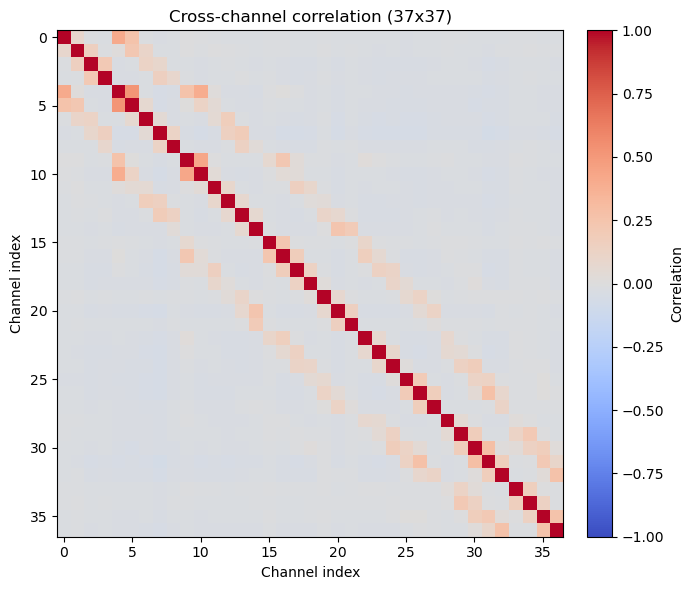

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(7.0, 6.0))
im = ax.imshow(cross_corr, cmap='coolwarm', vmin=-1, vmax=1, interpolation='nearest')
ax.set_title('Cross-channel correlation (37x37)')
ax.set_xlabel('Channel index')
ax.set_ylabel('Channel index')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Correlation')
plt.tight_layout()
plt.show()


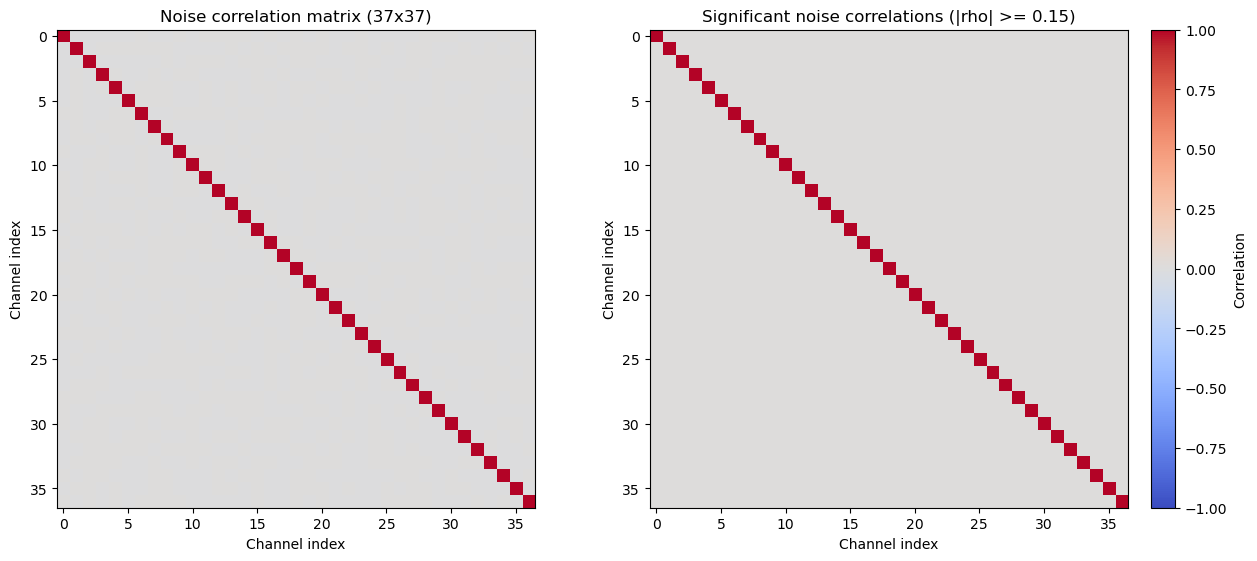

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.5), constrained_layout=True)

im0 = axes[0].imshow(noise_corr, cmap='coolwarm', vmin=-1, vmax=1, interpolation='nearest')
axes[0].set_title('Noise correlation matrix (37x37)')
axes[0].set_xlabel('Channel index')
axes[0].set_ylabel('Channel index')

im1 = axes[1].imshow(noise_corr_significant, cmap='coolwarm', vmin=-1, vmax=1, interpolation='nearest')
axes[1].set_title(f'Significant noise correlations (|rho| >= {SIGNIFICANCE_ABS_THRESHOLD})')
axes[1].set_xlabel('Channel index')
axes[1].set_ylabel('Channel index')

cbar = fig.colorbar(im0, ax=axes.ravel().tolist(), fraction=0.035, pad=0.02)
cbar.set_label('Correlation')

plt.show()


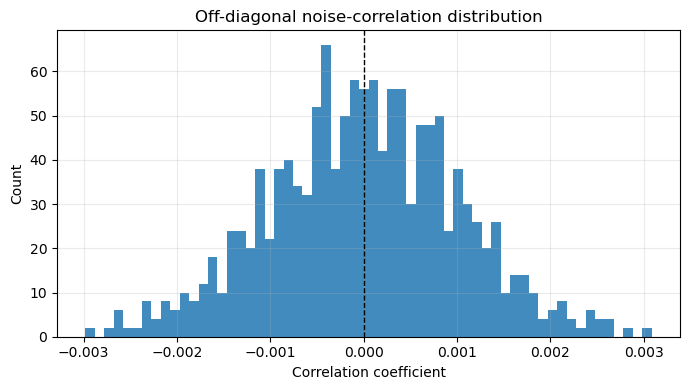

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(7.0, 4.0))
ax.hist(offdiag_vals, bins=60, alpha=0.85)
ax.axvline(0.0, color='k', linewidth=1.0, linestyle='--')
ax.set_title('Off-diagonal noise-correlation distribution')
ax.set_xlabel('Correlation coefficient')
ax.set_ylabel('Count')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
